In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
irisDataset = pd.read_csv("../../docs/iris/iris.data", 
                     names=["sepallength","sepalwidth",
                            "petallength","petalwidth","class"])

In [14]:
mappings = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
data = irisDataset.copy()
data['class'] = data['class'].map(mappings)

X_numpy = data.iloc[:, 0:4].values
y_numpy = data['class'].values

X = torch.tensor(X_numpy, dtype=torch.float32)
y = torch.tensor(y_numpy, dtype=torch.long)

In [15]:
class IrisData(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = IrisData(X, y)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

In [16]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(4, 10)
        self.fc2 = nn.Linear(10, 10)
        self.output = nn.Linear(10, 3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.output(x)
        return x

model = Net()

Época 10: Error = 0.2325
Época 20: Error = 0.0724
Época 30: Error = 0.0988
Época 40: Error = 0.0774
Época 50: Error = 0.0655
Época 60: Error = 0.0432
Época 70: Error = 0.0506
Época 80: Error = 0.0422
Época 90: Error = 0.0382
Época 100: Error = 0.0634


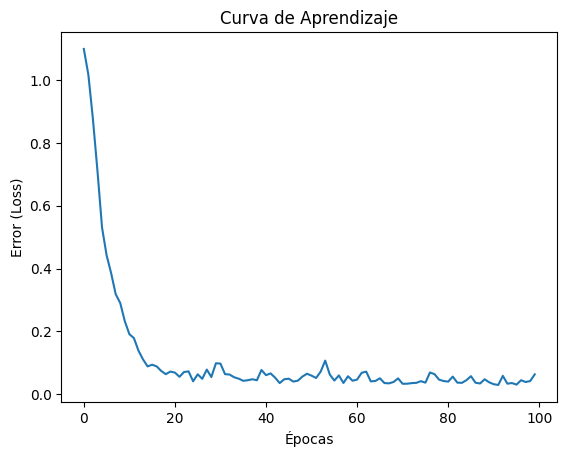

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100
loss_list = []

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()       
        outputs = model(inputs)     
        loss = criterion(outputs, labels) 
        loss.backward()             
        optimizer.step()            
        
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_list.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Época {epoch+1}: Error = {avg_loss:.4f}')

plt.plot(loss_list)
plt.title("Curva de Aprendizaje")
plt.xlabel("Épocas")
plt.ylabel("Error (Loss)")
plt.show()

In [18]:
model.eval() 
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisión del modelo en el set de prueba: {100 * correct / total:.2f}%')

Precisión del modelo en el set de prueba: 93.33%
